In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
df = pd.read_sql("SELECT timestamp as datetime FROM checker WHERE uid LIKE 'user%'", connection)
df

,datetime
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek
df['day_type'] = df['weekday'].apply(
    lambda x: 'weekend' if x >= 5 else 'working_day'
)

In [5]:
weekend_commits = df[df['day_type'] == 'weekend']['hour'] 
weekend_commits = list(weekend_commits)

In [6]:
weekday_commits = df[df['day_type'] == 'working_day']['hour'] 
weekday_commits = list(weekday_commits)

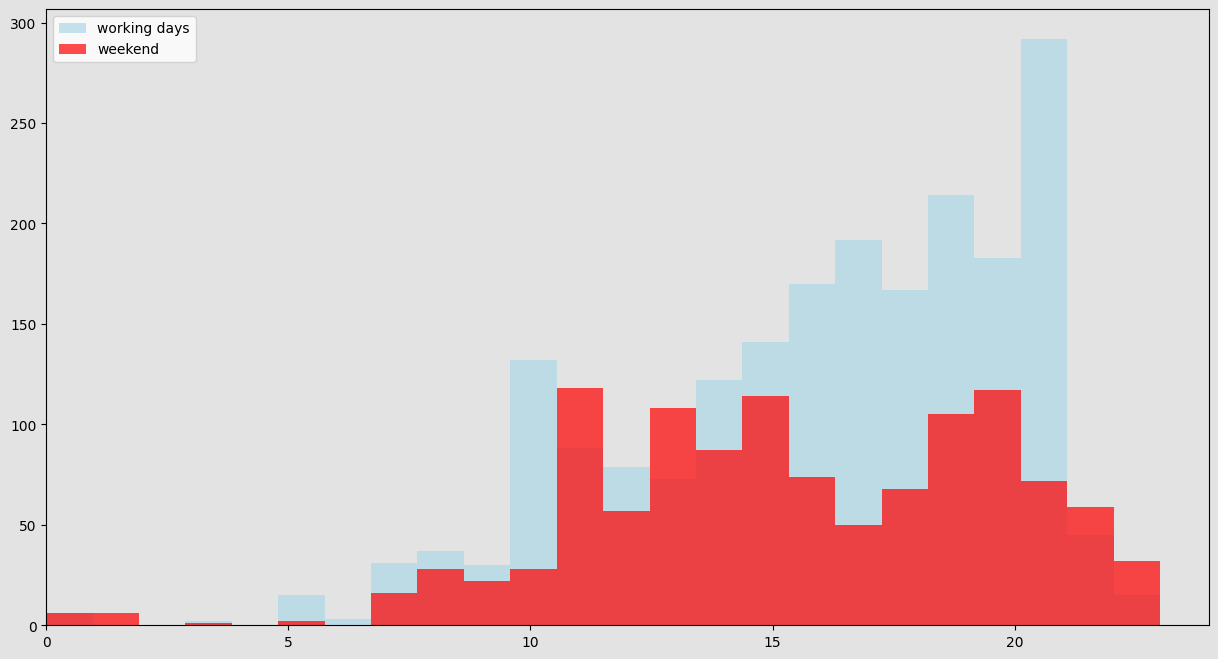

In [7]:
plt.figure(figsize=(15,8))
plt.hist(weekday_commits, bins=24, color='lightblue', alpha=0.7, label='working days')
plt.hist(weekend_commits, bins=24, color='red', alpha=0.7, label='weekend')

plt.xlim([0, 24])
plt.legend()
plt.gcf().set_facecolor('#E3E3E3')
plt.gca().set_facecolor('#E3E3E3')

In [8]:
connection.close()

«Были ли случаи, когда общее количество коммитов в выходные дни превышало количество коммитов в рабочие дни?» В своем ответе приведите четыре наиболее ярких примера.

**Да: 11, 13, 22, 23**